In [6]:
from PIL import Image

import ipywidgets as widgets
from IPython.display import display, HTML

import numpy as np
import colorsys

In [85]:
rgb_to_hsv = np.vectorize(colorsys.rgb_to_hsv)
hsv_to_rgb = np.vectorize(colorsys.hsv_to_rgb)

def shift_hue(arr, hout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    h = hout
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr

def shift_value(arr, vout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    v = np.clip(v*vout, 0, 255)
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr

def shift_saturation(arr, sout):
    r, g, b, a = np.rollaxis(arr, axis=-1)
    h, s, v = rgb_to_hsv(r, g, b)
    s = np.clip(s*sout, 0, 1.0)
    r, g, b = hsv_to_rgb(h, s, v)
    arr = np.dstack((r, g, b, a))
    return arr


def colorize(image, hue=None, value=None, saturation=None):
    """
    Colorize PIL image `original` with the given
    `hue` (hue within 0-360); returns another PIL image.
    """
    img = image.convert('RGBA')
    arr = np.array(np.asarray(img).astype('float'))
    
    if hue is not None:
        arr = shift_hue(arr, hue/360.)
        
    if value is not None:
        arr = shift_value(arr, value)
        
    if saturation is not None:
        arr = shift_saturation(arr, saturation)
    
    new_img = Image.fromarray(arr.astype('uint8'), 'RGBA')

    return new_img

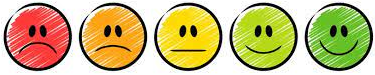

In [21]:
face_strip = Image.open('data/images/faces.png')
face_strip

In [26]:
faces = [ face_strip.crop( (i*75, 0, (i+1)*75, 75) ) for i in range(5) ]

In [33]:
happiness_spectrum = [ 'big frown', 'frown', 'neutral', 'smile', 'big smile' ]

@widgets.interact(
    happiness=happiness_spectrum,
    hue_rotation=(0, 360, 1))
def change_hue(hue_rotation: float, happiness):
    happiness_index = happiness_spectrum.index(happiness)
    face = faces[ happiness_index ]
    return colorize(face, hue_rotation)

interactive(children=(IntSlider(value=180, description='hue_rotation', max=360), Dropdown(description='happine…

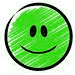

In [35]:
green_smile  = colorize(faces[3], 110)
green_smile

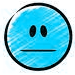

In [36]:
sad_mild = colorize(faces[2], 191)
sad_mild

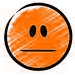

In [46]:
angry_mild = colorize(faces[2], 26)
angry_mild

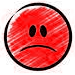

In [40]:
angry_severe = colorize(faces[1], 0)
angry_severe

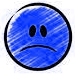

In [42]:
sad_severe = colorize(faces[1], 229)
sad_severe

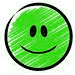

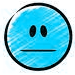

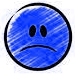

In [44]:
display(green_smile)
display(sad_mild)
display(sad_severe)

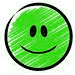

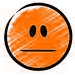

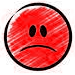

In [47]:
display(green_smile)
display(angry_mild)
display(angry_severe)

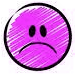

In [50]:
both_severe = colorize(faces[0], 296)
both_severe

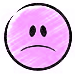

In [95]:
both_mild = colorize(faces[1], hue=296, saturation=0.4, value=1.5)
both_mild

In [96]:
green_smile.save('data/images/green_smile.png')
sad_mild.save('data/images/sad_mild.png')
sad_severe.save('data/images/sad_severe.png')
angry_mild.save('data/images/angry_mild.png')
angry_severe.save('data/images/angry_severe.png')
both_severe.save('data/images/both_severe.png')
both_mild.save('data/images/both_mild.png')